# **Week2 복습과제**

**1. [ANN]**

**2. [CNN]**

- 데이터는 Week 1 과 같이 MNIST (0-9 숫자 분류) 데이터셋입니다.
- 이때, 우리의 복습과제에서는 0-4 숫자 분류를 위한 데이터 샘플만 사용할 예정입니다
- 아래 코드를 실행시켜 주세요

In [1]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Subset
import random

# Tensor 변환을 위함
transform = transforms.Compose([
    transforms.ToTensor()
])

# MNIST 데이터셋 불러오기
train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = MNIST(root='./data', train=False, transform=transform, download=True)

# 무작위로 샘플 인덱스 선택
train_indices = [i for i, label in enumerate(train_dataset.targets) if label in [0, 1, 2, 3, 4]]
test_indices = [i for i, label in enumerate(test_dataset.targets) if label in [0, 1, 2, 3, 4]]

# Subset을 사용하여 샘플링된 데이터셋 생성
train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)


# DataLoader 생성
batch_size = 64  # 배치 크기는 64로 설정 (batch_size를 다르게 실행해보셔도 좋습니다)
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 15.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 476kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.38MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.62MB/s]


In [2]:
# 데이터셋 크기 확인을 위해 해당 셀을 실행시켜 주세요
print(f"Train dataset size: {len(train_subset)}")
print(f"Test dataset size: {len(test_subset)}")

Train dataset size: 30596
Test dataset size: 5139


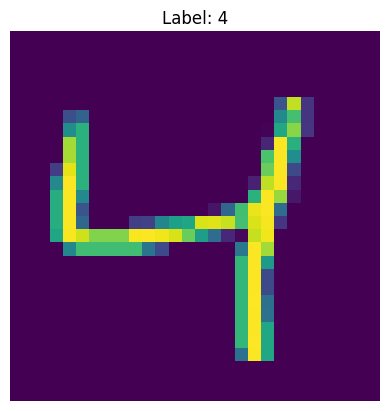

In [3]:
# 데이터셋 중 하나의 이미지를 시각화해보기
import matplotlib.pyplot as plt
import numpy as np

# 데이터셋에서 하나의 샘플 가져오기
image, label = train_subset[1]

# 텐서를 NumPy 배열로 변환
image = image.numpy().squeeze()

# 이미지 출력
plt.imshow(image)  # 이미지 표시
plt.title(f"Label: {label}")  # 레이블 표시
plt.axis("off")  # 축 없애기
plt.show()

<a id="1"></a> <br>
## **1. ANN**

**인공 신경망 (ANN)**

>  로지스틱 회귀는 분류 문제에서 성능이 좋지만, 데이터의 비선형성이 증가하면 모델의 정확도가 감소합니다.

>  따라서, hidden lyaer 에 더 많은 비선형 함수를 추가시켜 모델의 복잡도를 증가시켜 봅시다. 😀

↪ **3개의 hidden layer를 쌓고 다양한 활성화 함수 ReLU, Tanh, ELU 사용해봅시다**


In [4]:
# 필요한 라이브러리 임포트
import torch
import torch.nn as nn

#### **ANN 모델 생성**

In [6]:
import torch
import torch.nn as nn

class ANNModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ANNModel, self).__init__()

        # Linear function 1: input_dim --> hidden_dim  (입력 차원에서 숨겨진 계층으로)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Non-linearity 1 (ReLU 활성화 함수)
        self.relu1 = nn.ReLU()

        # Linear function 2: hidden_dim --> hidden_dim  (숨겨진 계층을 한 번 더 통과)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 2 (Tanh 활성화 함수 사용)
        self.tanh2 = nn.Tanh()

        # Linear function 3: hidden_dim --> hidden_dim (추가 숨겨진 계층)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 3 (ELU 활성화 함수)
        self.elu3 = nn.ELU()

        # Linear function 4: hidden_dim --> output_dim  (마지막 출력층)
        self.fc4 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Linear function 1
        out = self.fc1(x)
        # Non-linearity 1
        out = self.relu1(out)

        # Linear function 2
        out = self.fc2(out)
        # Non-linearity 2
        out = self.tanh2(out)

        # Linear function 3
        out = self.fc3(out)
        # Non-linearity 3
        out = self.elu3(out)

        # Linear function 4 (출력층)
        out = self.fc4(out)
        return out


In [8]:
# ANN 객체 생성
input_dim = 28 * 28  # 이미지 크기 (28x28)
hidden_dim = 150  # 하이퍼파라미터 (150으로 설정)
output_dim = 5  # 출력 클래스 개수 (0~4)


model = ANNModel(input_dim,hidden_dim,output_dim)
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss() # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

#### **ANN 모델 학습**

In [9]:
import torch
import torch.nn as nn

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트

# 전체 학습
for epoch in range(10):

    # 배치 단위 학습
    for i, (images, labels) in enumerate(train_loader):

        # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
        train = images.view(-1, 28 * 28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
        labels = labels  # 텐서 형태 유지

        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        # 모델을 이용해 예측값(outputs) 계산
        outputs = model(train)

        # 손실 계산
        # cross entropy loss를 사용해 예측값과 실제값 비교
        loss = loss_ftn(outputs, labels)

        # Backward propagation - 손실에 대한 기울기 계산
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            # 정확도 계산을 위한 변수 초기화
            correct = 0
            total = 0

            # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
            for images, labels in test_loader:
                test = images.view(-1, 28 * 28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환

                # Forward
                # 예측값 계산
                outputs = model(test)

                # 예측값 중 가장 높은 값을 선택
                predicted = torch.max(outputs.data, 1)[1]

                # 총 샘플 개수
                total += len(labels)

                # 올바르게 예측한 개수
                correct += (predicted == labels).sum()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if count % 500 == 0:
            # 손실 및 정확도 출력
            print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))


Iteration: 500  Loss: 0.1271992325782776  Accuracy: 96.22494506835938 %
Iteration: 1000  Loss: 0.05786069110035896  Accuracy: 97.31465148925781 %
Iteration: 1500  Loss: 0.2704874575138092  Accuracy: 97.60653686523438 %
Iteration: 2000  Loss: 0.06757836788892746  Accuracy: 97.6259994506836 %
Iteration: 2500  Loss: 0.17541776597499847  Accuracy: 97.7232894897461 %
Iteration: 3000  Loss: 0.028335828334093094  Accuracy: 97.93733978271484 %
Iteration: 3500  Loss: 0.09600715339183807  Accuracy: 98.1319351196289 %
Iteration: 4000  Loss: 0.059787265956401825  Accuracy: 98.20977020263672 %
Iteration: 4500  Loss: 0.06419398635625839  Accuracy: 98.1903076171875 %


#### **ANN 학습 결과**

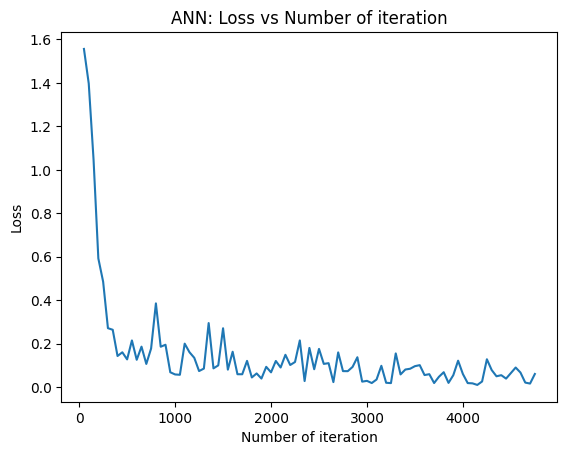

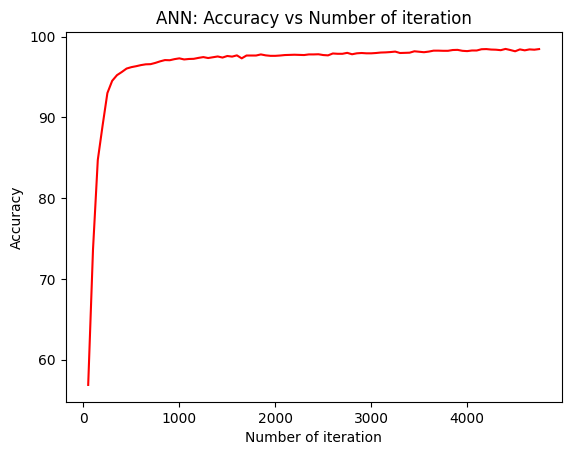

In [10]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 시각화된 모델의 학습 결과를 해석해주세요.** 🤗



---
**[해석]**

반복의 횟수가 많아질수록 Loss 값이 낮아지는 것을 알 수 있으며
마찬가지로 Accuracy도 증가하는 것을 확인할 수 있다


#### **ANN 최적의 하이퍼파라미터 찾기**

1️⃣ **실험 1: Hidden Dimension 최적값 찾기**
- hidden_dim 값을 50-200 사이 값들로 설정하고 모델을 학습
- 각 hidden_dim 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교




2️⃣ **실험 2: Learning Rate 최적값 찾기**

- learning_rate 값을 0.1-0.005 사이 값들로 설정하고 모델을 학습
- 각 learning_rate 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교



**⚠ 이때 epoch 값은 자유롭게 해주셔도 됩니다! **

Training with hidden_dim=50...
Training with hidden_dim=100...
Training with hidden_dim=150...
Training with hidden_dim=200...


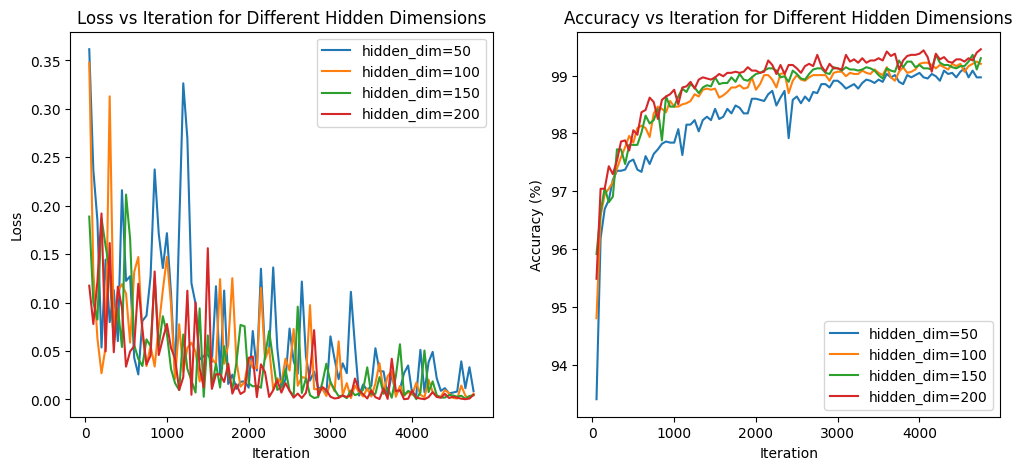

In [29]:
# 실험 1 hidden_dims=[50-200 사이 값들] 로 학습
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 하이퍼파라미터 설정
hidden_dims = [50, 100, 150, 200]  # 다양한 hidden_dim 값들
input_dim = 28 * 28  # 입력 차원 (MNIST 이미지 크기)
output_dim = 10  # 클래스 개수 (0~9)

# 데이터 로더
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

# 손실 및 정확도 저장용 딕셔너리
loss_dict = {}
accuracy_dict = {}

# 다양한 hidden_dim 값에 대해 학습 수행
for hidden_dim in hidden_dims:
    print(f"Training with hidden_dim={hidden_dim}...")

    # 모델 정의
    model = nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, output_dim)
    )

    # 손실 함수 및 옵티마이저 정의
    loss_ftn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # 학습을 모니터링하기 위한 변수들
    count = 0
    loss_list = []
    iteration_list = []
    accuracy_list = []

    # 전체 학습 반복
    for epoch in range(10):
        for i, (images, labels) in enumerate(train_loader):
            train = images.view(-1, input_dim)
            labels = labels

            optimizer.zero_grad()

            # Forward
            outputs = model(train)
            loss = loss_ftn(outputs, labels)

            # Backward
            loss.backward()
            optimizer.step()

            count += 1

            if count % 50 == 0:
                # 정확도 평가
                correct = 0
                total = 0
                with torch.no_grad():
                    for images, labels in test_loader:
                        test = images.view(-1, input_dim)
                        outputs = model(test)
                        predicted = torch.max(outputs.data, 1)[1]
                        total += len(labels)
                        correct += (predicted == labels).sum()

                accuracy = 100 * correct / float(total)

                # 손실 및 정확도 저장
                loss_list.append(loss.item())
                iteration_list.append(count)
                accuracy_list.append(accuracy.item())

    # 결과 저장
    loss_dict[hidden_dim] = (iteration_list, loss_list)
    accuracy_dict[hidden_dim] = (iteration_list, accuracy_list)

# 그래프 시각화
plt.figure(figsize=(12, 5))

# Loss 비교 그래프
plt.subplot(1, 2, 1)
for hidden_dim, (iter_list, loss_list) in loss_dict.items():
    plt.plot(iter_list, loss_list, label=f'hidden_dim={hidden_dim}')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss vs Iteration for Different Hidden Dimensions")
plt.legend()

# Accuracy 비교 그래프
plt.subplot(1, 2, 2)
for hidden_dim, (iter_list, accuracy_list) in accuracy_dict.items():
    plt.plot(iter_list, accuracy_list, label=f'hidden_dim={hidden_dim}')
plt.xlabel("Iteration")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Iteration for Different Hidden Dimensions")
plt.legend()

plt.show()


**해당 셀의 마크 다운을 풀고 hidden dimension 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
- 신경망의 표현력을 결정하는 중요한 하이퍼파라미터이다
- 값이 너무 작으면 과소적합이 발생할 수 있으며, 반대로 너무 많으면 과적합이 발생할 수 있다
- 적절한 값을 선택하면 모델이 적절한 복잡도를 유지하면서 학습이 가능하다


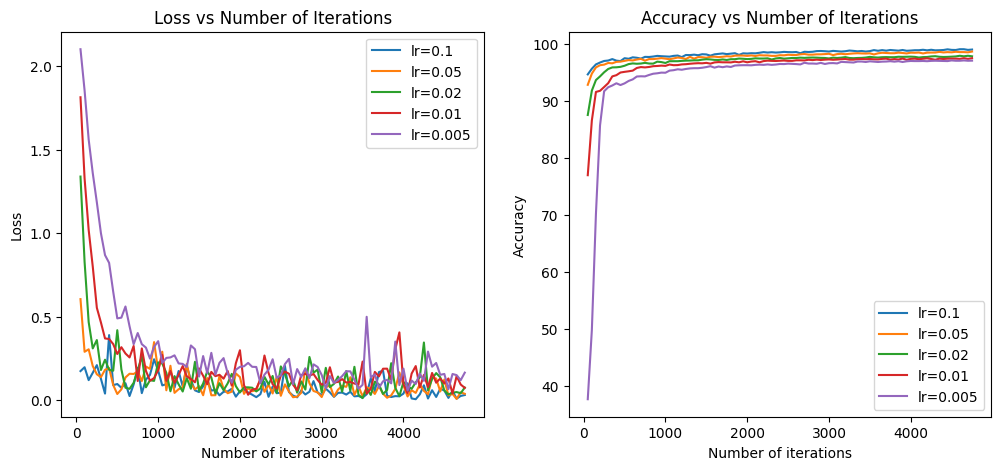

In [30]:
# 실험 2 learning_rates=[0.1-0.005 사이 값들] 로 학습
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 학습을 위한 설정
learning_rates = [0.1, 0.05, 0.02, 0.01, 0.005]  # 다양한 learning_rate 값들
num_epochs = 10  # 학습 횟수

# 결과 저장을 위한 딕셔너리
results = {}

for lr in learning_rates:
    # 모델 초기화
    model = ANNModel(input_dim=28*28, hidden_dim=100, output_dim=10)  # hidden_dim 고정
    loss_ftn = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    loss_list = []
    accuracy_list = []
    iteration_list = []
    count = 0

    for epoch in range(num_epochs):
        for i, (images, labels) in enumerate(train_loader):
            train = images.view(-1, 28 * 28)  # 1D 벡터 변환

            optimizer.zero_grad()
            outputs = model(train)
            loss = loss_ftn(outputs, labels)
            loss.backward()
            optimizer.step()

            count += 1

            if count % 50 == 0:
                correct = 0
                total = 0
                for images, labels in test_loader:
                    test = images.view(-1, 28 * 28)
                    outputs = model(test)
                    predicted = torch.max(outputs.data, 1)[1]
                    total += len(labels)
                    correct += (predicted == labels).sum()

                accuracy = 100 * correct / float(total)
                loss_list.append(loss.item())
                accuracy_list.append(accuracy)
                iteration_list.append(count)

    results[lr] = {'iterations': iteration_list, 'loss': loss_list, 'accuracy': accuracy_list}

# 그래프 출력
plt.figure(figsize=(12, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
for lr in learning_rates:
    plt.plot(results[lr]['iterations'], results[lr]['loss'], label=f'lr={lr}')
plt.xlabel("Number of iterations")
plt.ylabel("Loss")
plt.title("Loss vs Number of Iterations")
plt.legend()

# Accuracy 그래프
plt.subplot(1, 2, 2)
for lr in learning_rates:
    plt.plot(results[lr]['iterations'], results[lr]['accuracy'], label=f'lr={lr}')
plt.xlabel("Number of iterations")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Iterations")
plt.legend()

plt.show()


**해당 셀의 마크 다운을 풀고 learning rate 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
- 신경망이 가중치를 얼마나 크게 변경할지 결정하는 값이다
- 너무 큰 경우에는 Loss가 빠르게 감소하여 최적값을 지나쳐버려 최적의 성능을 얻기 어렵다
- 너무 작은 경우에는 학습 속도가 매우 느려진다
- 일반적으로 0.010.1의 값을 선택한다

<a id="1"></a> <br>
## **2. CNN**
> CNN은 이미지 분류에 적합한 모델로, kernel을 이용해 feature map을 생성합니다

**↪ 2개의 합성곱 계층을 쌓고, 활성화 함수로 ReLU를 사용하며,Max Pooling layer를 적용해봅시다.**

#### **CNN 모델 생성**

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim

# CNN Model 정의
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # 합성곱 계층 1 (Conv Layer 1)
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 1
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)  # kernel size를 2로 설정

        # 합성곱 계층 2 (Conv Layer 2)
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2) # kernel size를 2로 설정

        # Fully Connected Layer
        self.fc1 = nn.Linear(32 * 4 * 4, 10)   # 입력 차원 및 출력 차원 지정

    def forward(self, x):
        # 합성곱 계층 1 + 활성화 함수
        out = self.cnn1(x)
        out = self.relu1(out)

        # Max Pooling 1
        out = self.maxpool1(out)

        # 합성곱 계층 2 + 활성화 함수
        out = self.cnn2(out)
        out = self.relu2(out)

        # Max Pooling 2
        out = self.maxpool2(out)

        # feature map을 flatten하게
        out = out.view(out.size(0), -1)

        # 완전 연결 계층
        out = self.fc1(out)

        return out


In [21]:
# CNN 객체 생성
model = CNNModel()
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss()  # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
optimizer = optim.SGD(model.parameters(), lr=0.1)  # 학습률을 자유롭게 설정해주세요

#### **CNN 모델 학습**

In [26]:
# CNN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트
num_epochs = 20  # 학습할 에포크 수 설정 -> 자유롭게 설정해주셔도 됩니다

for epoch in range(num_epochs):
    running_loss = 0.0  # 에포크별 손실 초기화

    for images, labels in train_loader:
        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        # The following line was incorrectly indented
        outputs = model(images) # Changed 'train' to 'images' as 'images' is the input data for the current batch

        # 손실 계산
        # 'error' was not defined. Assuming it should be 'loss_ftn'
        loss = loss_ftn(outputs, labels)

        # Backward
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # 손실 누적
        running_loss += loss.item()
        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            correct = 0
            total = 0

            with torch.no_grad():  # 평가
                for images, labels in test_loader:
                    # 모델 예측 수행
                    # The following line was incorrectly indented, and using 'test' instead of 'images'
                    outputs = model(images) # Changed 'test' to 'images'

                    # 가장 확률이 높은 클래스 선택
                    predicted = torch.max(outputs.data, 1)[1]

                    # 총 샘플 수 및 올바른 예측 개수 누적
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

    # 매 에포크마다 평균 손실 출력
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")

Epoch 1, Loss: 0.14775650367922866
Epoch 2, Loss: 0.039107030593704566
Epoch 3, Loss: 0.027915586778976213
Epoch 4, Loss: 0.02270338493742006
Epoch 5, Loss: 0.018286256324672404
Epoch 6, Loss: 0.016469461636029383
Epoch 7, Loss: 0.01403458168474733
Epoch 8, Loss: 0.012026525357852244
Epoch 9, Loss: 0.010477833639334432
Epoch 10, Loss: 0.009626032816586284
Epoch 11, Loss: 0.008384492376620934
Epoch 12, Loss: 0.007458447717557446
Epoch 13, Loss: 0.0064626174064115905
Epoch 14, Loss: 0.005424174630546709
Epoch 15, Loss: 0.0051312069037658435
Epoch 16, Loss: 0.004802119263211785
Epoch 17, Loss: 0.00421571342848208
Epoch 18, Loss: 0.003583922523173589
Epoch 19, Loss: 0.002929598922340106
Epoch 20, Loss: 0.002931767701957218


#### **CNN 학습 결과**

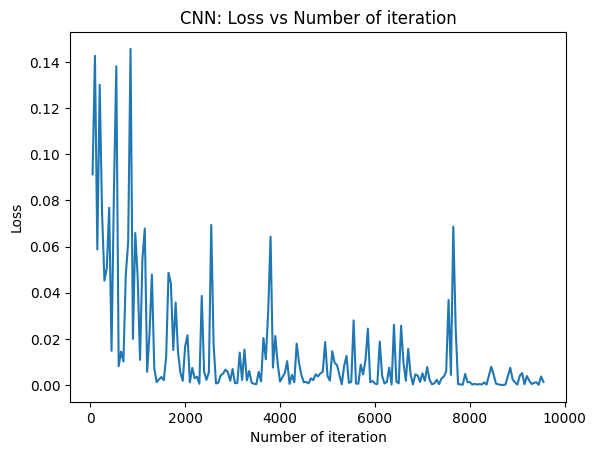

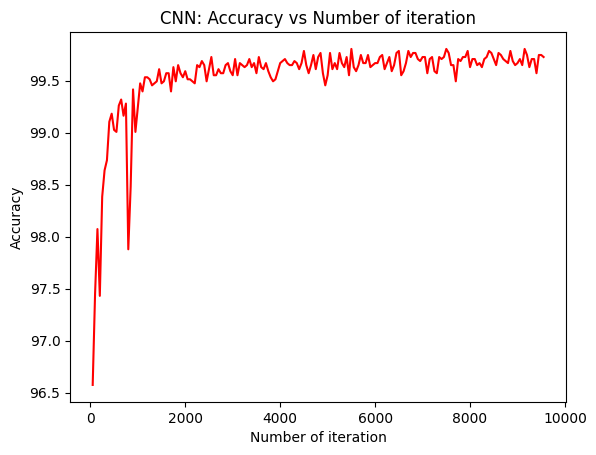

In [27]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("CNN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("CNN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 MNIST 데이터셋에서 ANN, CNN의 학습 결과 비교와 함께 두 모델에 대해 각각 짧게 소개해주세요.** 🤗



---
**[답변]**

- 두 모델 모두 학습이 진행됨에 따라 손실이 줄어들고 정확도는 향상하는 모습을 보였다

- CNN의 경우 이미지 데이터를 다룰 때 더 강력한 특징 추출 능력을 갖추고 있어 더 좋은 성능을 보일 수 있다

- ANN은 단순한 구조에서 효과적인 학습이 가능하다

